In [35]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

# ------------------------------------------------------------------
# Paths: replace these with the actual JRA and SPEEDY files/patterns.
# open_mfdataset accepts wildcards.
# ------------------------------------------------------------------
from pathlib import Path

JRA_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP")
SPEEDY_DIR = Path("/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing")

JRA_FILES = sorted(JRA_DIR.glob("tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1989*.nc")) + \
            sorted(JRA_DIR.glob("tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1990*.nc")) + \
            sorted(JRA_DIR.glob("tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_1991*.nc"))

SPEEDY_FILES = [
    SPEEDY_DIR / "tas_SPEEDY_1989.nc",
    SPEEDY_DIR / "tas_SPEEDY_1990.nc",
    SPEEDY_DIR / "tas_SPEEDY_1991.nc",
]

JRA_VARIABLE = "tas"
SPEEDY_VARIABLE = "tas"

[PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP/tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_198901010000-198912312100.nc'), PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP/tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_199001010000-199012312100.nc'), PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/INPUT/OMIP/tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-5-0_gr_199101010000-199112312100.nc')]
[PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing/tas_SPEEDY_1989.nc'), PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing/tas_SPEEDY_1990.nc'), PosixPath('/leonardo_scratch/fast/ICT26_ESP/ntilinin/SPEEDY_access/access_forcing/tas_SPEEDY_1991.nc')]


In [36]:
jra = xr.open_mfdataset(JRA_FILES, combine="by_coords", chunks={"time": 120})[JRA_VARIABLE]
speedy = xr.open_mfdataset(SPEEDY_FILES, combine="by_coords", chunks={"time": 120})[SPEEDY_VARIABLE]

print(jra.time.min().values, jra.time.max().values)
print(speedy.time.min().values, speedy.time.max().values)

1989-01-01T00:00:00.000000000 1991-12-31T21:00:00.000000000
1989-01-01 00:00:00 1991-12-31 18:00:00


/scratch_local/ipykernel_936316/456785827.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  jra = xr.open_mfdataset(JRA_FILES, combine="by_coords", chunks={"time": 120})[JRA_VARIABLE]


In [37]:
jra_mean = jra.mean("time", skipna=True).compute()
print("JRA mean done")

speedy_mean = speedy.mean("time", skipna=True).compute()
print("SPEEDY mean done")

JRA mean done
SPEEDY mean done


In [38]:
def normalize_lon(da):
    return da.assign_coords(
        lon=((da.lon + 180) % 360) - 180
    ).sortby("lon")


jra_mean = normalize_lon(jra_mean)
speedy_mean = normalize_lon(speedy_mean)

In [39]:
speedy_on_jra = speedy_mean.interp(
    lat=jra_mean.lat,
    lon=jra_mean.lon,
)

difference_mean = speedy_on_jra - jra_mean
reference_mean = jra_mean - 273.15
candidate_mean = speedy_on_jra - 273.15

# Difference in K == difference in °C
difference_mean = speedy_on_jra - jra_mean

reference_mean.attrs["units"] = "°C"
candidate_mean.attrs["units"] = "°C"
difference_mean.attrs["units"] = "°C"

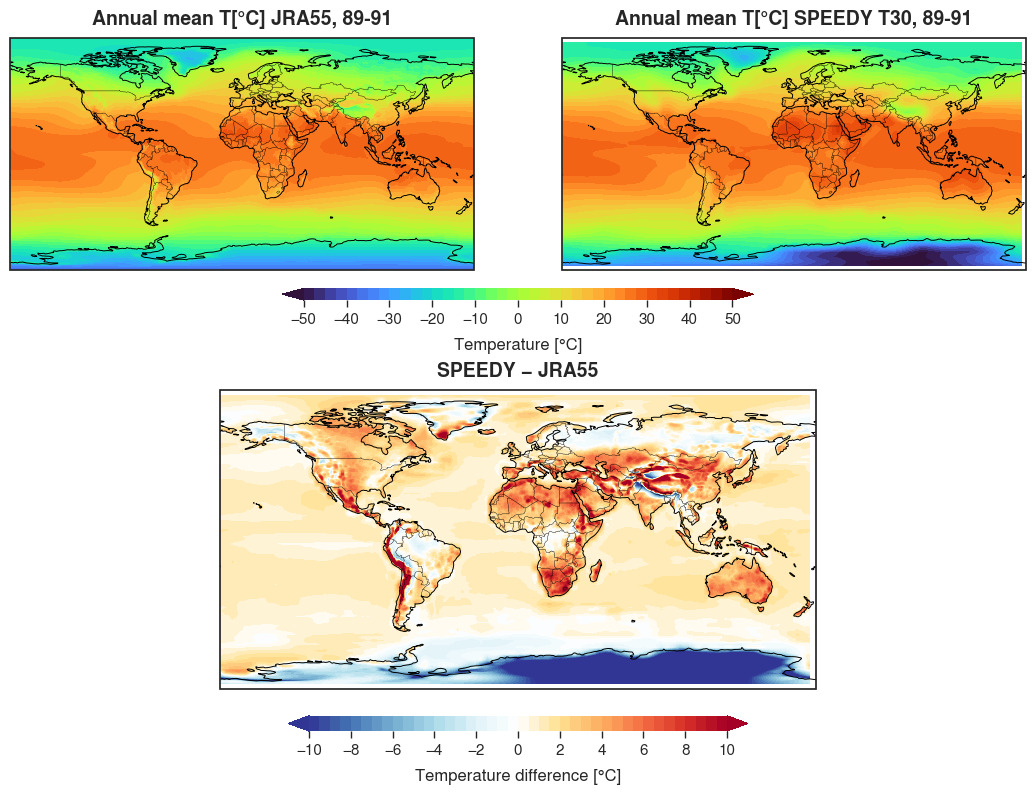

In [40]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

temp_cmap = plt.get_cmap("turbo")

diff_cmap = LinearSegmentedColormap.from_list(
    "TemperatureBlueWhiteRed",
    ["#313695","#4575b4","#74add1","#abd9e9","#e0f3f8","#ffffff",
     "#fee090","#fdae61","#f46d43","#d73027","#a50026"],
    N=256
)

temp_levels = np.arange(-50, 52.5, 2.5)
temp_norm = mcolors.TwoSlopeNorm(vmin=-50, vcenter=0, vmax=50)
temp_ticks = np.arange(-50, 51, 10)

diff_levels = np.arange(-10, 10.5, 0.5)
diff_norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
diff_ticks = np.arange(-10, 11, 2)

def make_cyclic(da):
    data, lon = add_cyclic_point(da.values, coord=da.lon.values, axis=da.get_axis_num("lon"))
    return data, lon

def setup_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

fig = plt.figure(figsize=(14, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.3], hspace=0.3, wspace=0.12)

ax1 = fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 0:6], projection=ccrs.PlateCarree())

# JRA55
data, lon = make_cyclic(reference_mean)
im1 = ax1.contourf(lon, reference_mean.lat.values, data, levels=temp_levels,
                   norm=temp_norm, cmap=temp_cmap, transform=ccrs.PlateCarree(), extend="both")
setup_map(ax1)
ax1.set_title("Annual mean T[°C] JRA55, 89-91", fontsize=14, fontweight="bold", pad=10)

# SPEEDY
data, lon = make_cyclic(candidate_mean)
im2 = ax2.contourf(lon, candidate_mean.lat.values, data, levels=temp_levels,
                   norm=temp_norm, cmap=temp_cmap, transform=ccrs.PlateCarree(), extend="both")
setup_map(ax2)
ax2.set_title("Annual mean T[°C] SPEEDY T30, 89-91", fontsize=14, fontweight="bold", pad=10)

# Difference
data, lon = make_cyclic(difference_mean)
im3 = ax3.contourf(lon, difference_mean.lat.values, data, levels=diff_levels,
                   norm=diff_norm, cmap=diff_cmap, transform=ccrs.PlateCarree(), extend="both")
setup_map(ax3)
ax3.set_title("SPEEDY − JRA55", fontsize=14, fontweight="bold", pad=10)

# Colorbars
cbar1 = fig.colorbar(im1, ax=[ax1, ax2], orientation="horizontal",
                     fraction=0.045, pad=0.07, aspect=40, ticks=temp_ticks)
cbar1.set_label("Temperature [°C]", fontsize=12, labelpad=8)
cbar1.ax.tick_params(labelsize=11, length=5, width=1)
cbar1.outline.set_visible(False)

cbar2 = fig.colorbar(im3, ax=ax3, orientation="horizontal",
                     fraction=0.045, pad=0.08, aspect=30, ticks=diff_ticks)
cbar2.set_label("Temperature difference [°C]", fontsize=12, labelpad=8)
cbar2.ax.tick_params(labelsize=11, length=5, width=1)
cbar2.outline.set_visible(False)

fig.savefig("../figures/diff_annual_mean_T_1989_1991_6h.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
# 1990 only
jra_1990 = jra.sel(time=slice("1990-01-01", "1990-12-31"))
speedy_1990 = speedy.sel(time=slice("1990-01-01", "1990-12-31"))

def area_weighted_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    return da.weighted(weights).mean(("lat", "lon"))

jra_global = area_weighted_mean(jra_1990).compute() - 273.15
print("JRA done")

speedy_global = area_weighted_mean(speedy_1990).compute() - 273.15
print("SPEEDY done")

JRA done
SPEEDY done


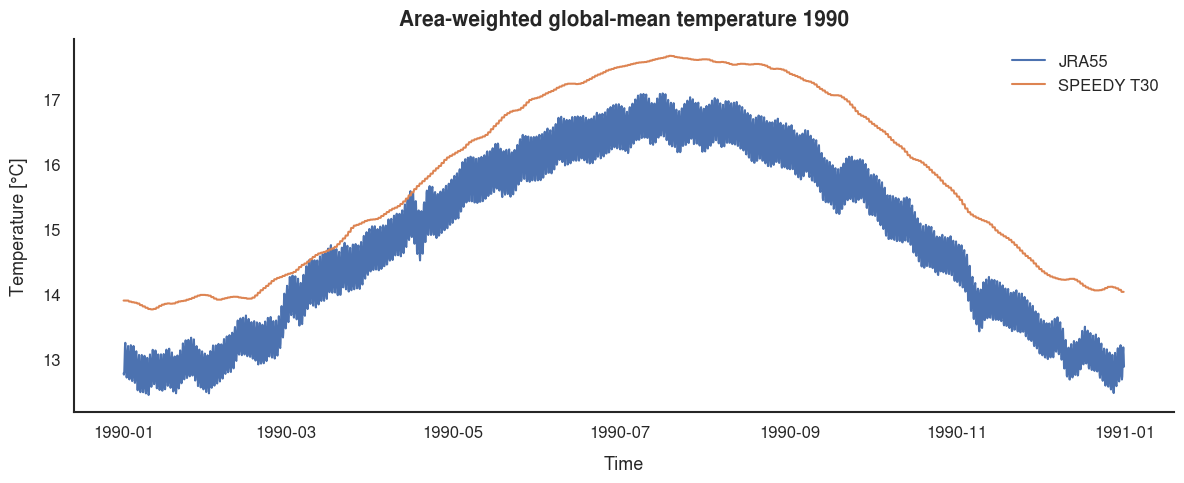

In [45]:
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(jra_global.time, jra_global, linewidth=1.5, label="JRA55")
ax.plot(speedy_global.time, speedy_global, linewidth=1.5, label="SPEEDY T30")

ax.set_title("Area-weighted global-mean temperature 1990", fontsize=15, fontweight="bold", pad=10)
ax.set_ylabel("Temperature [°C]", fontsize=13, labelpad=10)
ax.set_xlabel("Time", fontsize=13, labelpad=10)

ax.tick_params(axis="both", direction="out", length=6, width=1.2, labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig("../figures/global_mean_T_timeseries_1989_1991.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
jra_stats = {
    "Mean": float(jra_global.mean().compute()),
    "Min": float(jra_global.min().compute()),
    "Max": float(jra_global.max().compute()),
}

speedy_stats = {
    "Mean": float(speedy_global.mean().compute()),
    "Min": float(speedy_global.min().compute()),
    "Max": float(speedy_global.max().compute()),
}

print("JRA55:", jra_stats)
print("SPEEDY:", speedy_stats)

JRA55: {'Mean': 14.880599089160786, 'Min': 12.451156516763547, 'Max': 17.09059659536024}
SPEEDY: {'Mean': 15.800198482043342, 'Min': 13.767844083465775, 'Max': 17.66848711964292}
